In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load datasets

nav = pd.read_csv("02_nav_history_cleaned.csv")
performance = pd.read_csv("07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("09_portfolio_holdings_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: '02_nav_history_cleaned.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\DELL\Desktop\Bluestock_MF_Capstone


In [4]:
import os
print(os.listdir())

['.git', '.ipynb_checkpoints', 'Advanced_Analytics.ipynb', 'alpha_beta.csv', 'amfi_validation.py', 'bluestock_mf.db', 'bluestock_mf_dashboard.pbix', 'charts', 'create_remaining_cleaned_files.py', 'dashboards', 'data', 'data_dictionary.md', 'data_ingestion.py', 'day2_cleaning.py', 'EDA_Analysis.ipynb', 'fund_master_explore.py', 'fund_scorecard.csv', 'live_nav_fetch.py', 'max_drawdown.csv', 'notebooks', 'Performance_Analytics.ipynb', 'queries.sql', 'reports', 'requirements.txt', 'schema.sql', 'sql', 'sqlite_loader.py', 'tracking_error.csv', 'verify_db.py']


In [5]:
import os

print(os.listdir("data"))

['processed', 'raw']


In [6]:
import os

print(os.listdir("data/processed"))

['01_fund_master_cleaned.csv', '02_nav_history_cleaned.csv', '03_aum_by_fund_house_cleaned.csv', '04_monthly_sip_inflows_cleaned.csv', '05_category_inflows_cleaned.csv', '06_industry_folio_count_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv', '09_portfolio_holdings_cleaned.csv', '10_benchmark_indices_cleaned.csv']


In [7]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [8]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)
print(portfolio.shape)

(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [9]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Remove first NaN return of each fund
returns = nav.dropna(subset=["daily_return"])

print(returns.head())

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


In [10]:
# Historical VaR (95%) and CVaR

var_cvar = returns.groupby("amfi_code")["daily_return"].apply(
    lambda x: pd.Series({
        "VaR_95": np.percentile(x, 5),
        "CVaR_95": x[x <= np.percentile(x, 5)].mean()
    })
).unstack()

# Display first few rows
print(var_cvar.head())

             VaR_95   CVaR_95
amfi_code                    
100016    -0.014364 -0.018060
100025    -0.003793 -0.004994
100033    -0.019034 -0.023456
101206    -0.013282 -0.017439
101207    -0.026021 -0.032459


In [11]:
var_cvar.to_csv("var_cvar_report.csv")

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [12]:
# Risk-free rate
rf = 0.065

# Daily risk-free rate
daily_rf = rf / 252

# Rolling Sharpe Ratio
returns["rolling_sharpe"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x:
        ((x.rolling(90).mean() - daily_rf) /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

print(returns.head())

   amfi_code       date       nav  daily_return  rolling_sharpe
1     100016 2022-01-04  515.0971     -0.010306             NaN
2     100016 2022-01-05  521.7239      0.012865             NaN
3     100016 2022-01-06  515.7880     -0.011377             NaN
4     100016 2022-01-07  515.1639     -0.001210             NaN
5     100016 2022-01-10  510.7136     -0.008639             NaN


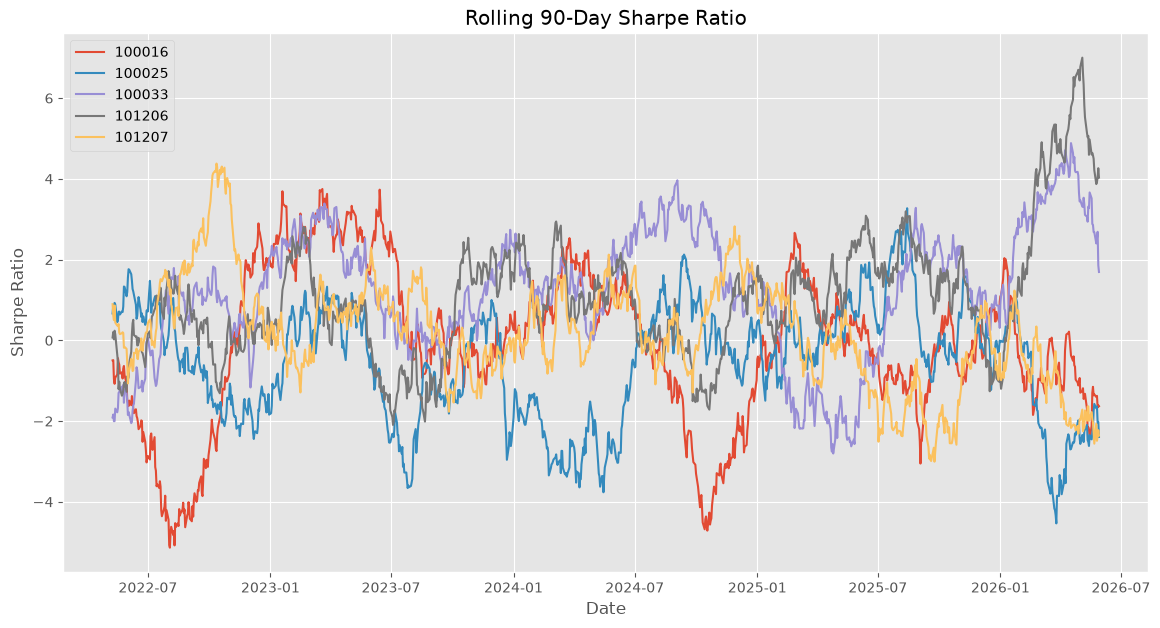

In [13]:
import matplotlib.pyplot as plt

# First 5 AMFI codes
top5 = returns["amfi_code"].unique()[:5]

plt.figure(figsize=(14,7))

for code in top5:
    temp = returns[returns["amfi_code"] == code]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(code))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png", dpi=300)
plt.show()

In [14]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [15]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Find each investor's first transaction year
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

print(transactions[["investor_id", "transaction_date", "cohort_year"]].head())

  investor_id transaction_date  cohort_year
0   INV003054       2024-01-01         2024
1   INV002952       2024-01-01         2024
2   INV003420       2024-01-01         2024
3   INV003436       2024-01-01         2024
4   INV004691       2024-01-01         2024


In [16]:
# Cohort Analysis
cohort_analysis = transactions.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    total_transactions=("investor_id", "count")
)

print(cohort_analysis)

             avg_sip_amount  total_invested  total_transactions
cohort_year                                                    
2024          107422.541832      3491125187               32499
2025          109158.577061        30455243                 279


In [17]:
# Top fund (AMFI code) for each cohort
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

print(top_fund)

    cohort_year  amfi_code  count
35         2024     148568    874
62         2025     119599     12


In [18]:
cohort_report = cohort_analysis.merge(
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year"
)

print(cohort_report)

   cohort_year  avg_sip_amount  total_invested  total_transactions  amfi_code
0         2024   107422.541832      3491125187               32499     148568
1         2025   109158.577061        30455243                 279     119599


In [19]:
# Keep only SIP transactions
sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

print(sip.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
5   INV001497       2024-01-01     101208              Sip        3295   
6   INV000786       2024-01-01     101208              Sip       15047   

            state       city city_tier age_group  gender  annual_income_lakh  \
0       Telangana  Hyderabad       T30       56+  Female                77.1   
2         Haryana  Faridabad       B30     36-45    Male                47.2   
3     Maharashtra     Mumbai       T30     36-45  Female                54.4   
5     Maharashtra     Mumbai       T30     36-45    Male                56.8   
6  Madhya Pradesh     Bhopal       B30     26-35    Male                17.9   

  payment_mode kyc_status  cohort_year  
0          UPI   Verified        

In [20]:
sip = sip.sort_values(["investor_id", "transaction_date"])

In [21]:
# Gap between SIP transactions
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

print(sip.head())

      investor_id transaction_date  amfi_code transaction_type  amount_inr  \
19621   INV000001       2024-11-04     120505              Sip       44856   
24448   INV000001       2025-01-19     125497              Sip        3090   
5650    INV000002       2024-03-29     149322              Sip        2830   
16803   INV000002       2024-09-21     120841              Sip        2354   
31881   INV000002       2025-05-17     119094              Sip        2690   

             state      city city_tier age_group gender  annual_income_lakh  \
19621      Haryana  Gurugram       T30     36-45   Male                19.9   
24448      Haryana  Gurugram       T30     36-45   Male                19.9   
5650   Maharashtra      Pune       T30     46-55   Male                24.0   
16803  Maharashtra      Pune       T30     46-55   Male                24.0   
31881  Maharashtra      Pune       T30     46-55   Male                24.0   

      payment_mode kyc_status  cohort_year  gap_days  
1

In [22]:
sip_analysis = sip.groupby("investor_id").agg(
    sip_count=("transaction_date", "count"),
    avg_gap_days=("gap_days", "mean")
)

# Keep investors with 6 or more SIPs
sip_analysis = sip_analysis[sip_analysis["sip_count"] >= 6]

# Flag at-risk investors
sip_analysis["status"] = sip_analysis["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Active"
)

print(sip_analysis.head())

             sip_count  avg_gap_days   status
investor_id                                  
INV000004            6     85.400000  At Risk
INV000008            6     70.400000  At Risk
INV000010            6     64.800000  At Risk
INV000011            7     40.166667  At Risk
INV000012            8     57.000000  At Risk


In [23]:
sip_analysis.to_csv("sip_continuity_report.csv")

print("✅ sip_continuity_report.csv created successfully!")

✅ sip_continuity_report.csv created successfully!


In [24]:
%%writefile recommender.py

import pandas as pd

# Load performance data
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

def recommend_funds(risk):
    risk = risk.capitalize()

    funds = performance[
        performance["risk_grade"].str.capitalize() == risk
    ]

    funds = funds.sort_values(
        by="sharpe_ratio",
        ascending=False
    )

    print("\nTop 3 Recommended Funds\n")
    print(
        funds[
            [
                "scheme_name",
                "fund_house",
                "category",
                "risk_grade",
                "sharpe_ratio"
            ]
        ].head(3)
    )

risk = input("Enter Risk Appetite (Low / Moderate / High): ")
recommend_funds(risk)

Writing recommender.py


In [25]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [ ]:
# Convert weight percentage to decimal
portfolio["weight_decimal"] = portfolio["weight_pct"] / 100

# Calculate HHI for each fund
hhi = (
    portfolio.groupby("amfi_code")["weight_decimal"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

print(hhi.head())

In [27]:
hhi_report = hhi.merge(
    performance[["amfi_code", "scheme_name", "category"]],
    on="amfi_code"
)

# Equity funds only
equity_hhi = hhi_report[
    hhi_report["category"].str.contains("Equity", case=False, na=False)
]

# Highest concentration first
equity_hhi = equity_hhi.sort_values("HHI", ascending=False)

print(equity_hhi.head())

Empty DataFrame
Columns: [amfi_code, HHI, scheme_name, category]
Index: []


In [28]:
equity_hhi.to_csv("sector_hhi_report.csv", index=False)

print("✅ sector_hhi_report.csv created successfully!")

✅ sector_hhi_report.csv created successfully!


Advanced Insights

  1.  Historical VaR & CVaR

Funds with higher VaR and CVaR experienced larger potential daily losses, indicating higher downside risk.

  2.  Rolling Sharpe Ratio

The rolling 90-day Sharpe Ratio showed that fund performance varied over time, with some funds consistently delivering better risk-adjusted returns.

  3.  Investor Cohort Analysis

Investors who joined in 2024 contributed the highest investment amount and transaction volume, making them the largest investor cohort.

  4.  SIP Continuity Analysis

Investors with an average SIP gap greater than 35 days were identified as At Risk, helping identify potential discontinuation trends.

  5.  Sector HHI Concentration

Funds with higher HHI values had more concentrated portfolios, while lower HHI values indicated better diversification across sectors.